# Predicting OIV 452-1 grapevine downy-mildew resistance scores with the released Swin CORN scorer

**Paper:** Duarte-Carvajalino et al., *Phenotyping grapevine resistance to downy mildew: deep learning as a promising tool to assess sporulation and necrosis*, **Plant Methods 20:90 (2024)**, DOI [10.1186/s13007-024-01220-4](https://doi.org/10.1186/s13007-024-01220-4) (open access, PMC11177444).

**Author code:** [treizh/oiv_ld_phenotyping](https://huggingface.co/treizh/oiv_ld_phenotyping) (AGPL-3.0), pinned revision `9afe4997f9a24334760db4f8ee97e1fa56398429`. The model class `OivDetPatchesNet` (`src/leaf_patch_oiv_predictor_model.py`) is a PyTorch-Lightning module: a Hugging Face Swin-tiny encoder plus a rank-consistent **CORN** ordinal head that predicts the OIV 452-1 resistance score (levels 1, 3, 5, 7, 9).

**Scope (partial demonstration):** inference only. We predict OIV 452-1 scores for 15 leaf-patch images from the released test split (`data/oiv_test.csv`) with the released checkpoint `checkpoints/oiv_scorer/oiv_scorer.ckpt`, using the author's own code, and compare predictions with the expert-annotated scores. Training, the leaf-disc detector, plate indexing and the genotype-differentiation ANOVA are **not** reproduced. A 15-image run is not a verification of the paper's dataset-level metrics (test MAE 0.188 on the 0–4 scale).

**実行内容（日本語）:** 論文の著者コードと公開チェックポイントをそのまま使い、テスト分割から決定的に選んだ15枚の葉パッチ画像について OIV 452-1 スコアを予測し、専門家のアノテーションと比較します。学習やデータセット全体の評価は対象外です。

**Execution status:** executed on Google Colab (see the validation record cell at the end). Expected end-to-end time ≈ 10–15 min; downloads ≈ 0.6 GB (CPU) or ≈ 3 GB (GPU, CUDA wheels).

## Runtime selection and how to run

Select **Runtime → Run all**. The notebook works on both a **CPU** and a **T4 GPU** runtime; on CPU the scientific result is identical and the demo takes only a few extra seconds (Swin-tiny inference on 15 images ≈ 5 s CPU). The only runtime-dependent branch is which torch wheel is installed; the method, sample, checkpoint, preprocessing and calculations are the same on both.

**CPU を選択した場合でも同じ結果が得られます（推奨）。GPU(T4) も利用できます。**

Adaptations (documented deviations from the author's `requirements.txt`, forced by today's Colab Python 3.13):
- `torch==2.5.1` instead of `torch==2.3.0` (no Python 3.13 wheels exist for 2.3.0). `torchvision` is omitted: the inference path never imports it.
- `transformers==4.45.2` (the author left it unpinned; 4.46+ imports torch ≥ 2.6 internals).
- `pandas==2.2.3` with `siuba --no-deps` (siuba pins `pandas<2.1`, whose sdist does not build on Python 3.13; siuba 0.4.4 itself was verified to work with pandas 2.x + NumPy 2).
- NumPy stays at the Colab-provided 2.x instead of the author's `numpy==1.26.4` (no Python 3.13 wheels).
- After loading the checkpoint we set `model.path_to_images` and the device — the same override the authors perform in their own prediction notebook (cell *Validate* of `src/leaf_patch_oiv_predictor.ipynb`).

### Install dependencies

Installs the pinned inference stack. On a GPU runtime the standard PyPI torch wheel (CUDA build) is installed; on a CPU runtime the smaller CPU wheel is used. All packages are installed by notebook cells so a fresh runtime is self-contained.

**依存パッケージをインストールします。GPU/CPU ランタイムに応じて適切な torch を選びます。**

In [ ]:
import subprocess, sys

def pip_run(args):
    print("+", " ".join(args), flush=True)
    r = subprocess.run(args, capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stdout[-4000:]); print(r.stderr[-2000:])
        raise RuntimeError(f"pip failed: {' '.join(args)}")
    return r

try:
    has_gpu = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).returncode == 0
except FileNotFoundError:
    has_gpu = False
print("GPU runtime:", has_gpu)

if has_gpu:
    pip_run([sys.executable, "-m", "pip", "install", "torch==2.5.1",
             "--timeout", "120", "--retries", "5"])
else:
    pip_run([sys.executable, "-m", "pip", "install", "torch==2.5.1",
             "--index-url", "https://download.pytorch.org/whl/cpu",
             "--timeout", "120", "--retries", "5"])

pip_run([sys.executable, "-m", "pip", "install",
         "pytorch-lightning==2.2.4", "torchmetrics==1.4.0", "coral-pytorch",
         "albumentations==1.4.4", "rich", "transformers==4.45.2",
         "pandas==2.2.3", "opencv-python-headless", "scikit-learn", "tqdm",
         "--timeout", "120", "--retries", "5"])
# siuba pins pandas<2.1 (no py3.13 wheels); its code itself works with pandas 2.x
pip_run([sys.executable, "-m", "pip", "install", "--no-deps", "siuba",
         "--timeout", "120", "--retries", "5"])

import torch, pytorch_lightning, albumentations, transformers, pandas, siuba
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("pytorch-lightning", pytorch_lightning.__version__, "| transformers", transformers.__version__)
print("albumentations", albumentations.__version__, "| pandas", pandas.__version__)

GPU runtime: True
+ /usr/bin/python3 -m pip install torch==2.5.1 --timeout 120 --retries 5


+ /usr/bin/python3 -m pip install pytorch-lightning==2.2.4 torchmetrics==1.4.0 coral-pytorch albumentations==1.4.4 rich transformers==4.45.2 pandas==2.2.3 opencv-python-headless scikit-learn tqdm --timeout 120 --retries 5


+ /usr/bin/python3 -m pip install --no-deps siuba --timeout 120 --retries 5


/usr/local/lib/python3.13/dist-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


torch

...

4.45.2

albumentations

1.4.4

| pandas

2.2.3

## Minimal input and weight acquisition

Everything is downloaded from the author's pinned Hugging Face revision `9afe4997f9a24334760db4f8ee97e1fa56398429` (AGPL-3.0) via plain HTTPS `resolve` URLs — no authentication and no PhenoPaper credentials are used:

- `src/*.py` — the author's model and helper modules (SHA-256 verified against the pinned revision),
- `checkpoints/oiv_scorer/oiv_scorer.ckpt` — the released Swin CORN scorer (332,151,646 bytes),
- `data/oiv_test.csv` — expert-annotated test split (semicolon separated),
- 15 leaf-patch PNGs from `images/leaf_patches/` (selected deterministically below).

**著者の固定リビジョンからコード・チェックポイント・テストCSV・画像をダウンロードし、検証します。**

In [ ]:
import urllib.request, hashlib, time
from pathlib import Path

SHA = "9afe4997f9a24334760db4f8ee97e1fa56398429"
BASE = f"https://huggingface.co/treizh/oiv_ld_phenotyping/resolve/{SHA}/"
ROOT = Path("/content/oiv_ld_phenotyping")

# SHA-256 of the author code files at the pinned revision (computed from the pinned tree)
CODE_FILES = {
    "src/com_const.py": "4e91979bf128ab7763482660a3107318630455979a04adebaead8b15a20b7685",
    "src/com_image.py": "fcc69905baea771c56b76f0a405285e89d4e7672d29a5cdbefadcbede055c815",
    "src/com_augmentations.py": "a5a570f903adf0901aa2d724a33b7ab320082166c200160977be8261095ee378",
    "src/com_func.py": "396bc0db8f6287f565881ea94d60be90df242b7d52d4821cb246d2f10d3d5e24",
    "src/com_plot.py": "5d1f812c5b8b660b63c019fdc3fb70eb50987401cdda754ab96462c2a589aa3a",
    "src/leaf_patch_oiv_predictor_model.py": "131bfd55e14facbba9b8d1da1b8e573f9edbf1b63df6e082b2a41fb5f95e88e0",
}

def fetch(rel, dst, expect_size=None, retries=3):
    dest = ROOT / dst
    dest.parent.mkdir(parents=True, exist_ok=True)
    for attempt in range(retries):
        try:
            urllib.request.urlretrieve(BASE + rel, dest)
            break
        except Exception as e:
            if attempt == retries - 1:
                raise
            time.sleep(5 * (attempt + 1))
    size = dest.stat().st_size
    assert expect_size is None or size == expect_size, f"size mismatch {rel}: {size}"
    return size

for rel, sha in CODE_FILES.items():
    fetch(rel, rel)
    h = hashlib.sha256((ROOT / rel).read_bytes()).hexdigest()
    assert h == sha, f"sha256 mismatch for {rel}"
    print(f"ok  {rel}  ({h[:12]}...)")

print("author code downloaded and verified at revision", SHA[:12])

ok  src/com_const.py  (4e91979bf128...)

ok  src/com_image.py  (fcc69905baea...)

ok  src/com_augmentations.py  (a5a570f903ad...)

ok  src/com_func.py  (396bc0db8f62...)

ok  src/com_plot.py  (5d1f812c5b8b...)

ok  src/leaf_patch_oiv_predictor_model.py  (131bfd55e14f...)

author code downloaded and verified at revision

9afe4997f9a2

### Download the scorer checkpoint and the annotated test split

The checkpoint is the authors' released `oiv_scorer.ckpt` (332 MB; contains the Swin-tiny weights, the CORN head, the training hyperparameters and the prepared train/val/test dataframes). `oiv_test.csv` holds the expert OIV 452-1 scores (1/3/5/7/9) for 517 patches.

**チェックポイント (332 MB) とテストCSVをダウンロードし、サイズを検証します。**

In [ ]:
ckpt_size = fetch("checkpoints/oiv_scorer/oiv_scorer.ckpt",
                  "checkpoints/oiv_scorer/oiv_scorer.ckpt", expect_size=332151646)
print(f"checkpoint ok: {ckpt_size:,} bytes")
csv_size = fetch("data/oiv_test.csv", "data/oiv_test.csv")
print(f"oiv_test.csv ok: {csv_size:,} bytes")

checkpoint ok: 332,151,646 bytes

oiv_test.csv ok: 50,663 bytes

### Select a deterministic sample and download the leaf-patch images

The demonstration uses **3 patches per OIV 452-1 class (1, 3, 5, 7, 9) = 15 patches**, chosen by sorting `oiv_test.csv` by `file_name` and taking the first rows of each class — a fixed, seed-free selection that does not favour any result. Patch file names map directly to `images/leaf_patches/`. Each image is verified to be decodable.

**各OIVクラスから3枚ずつ（計15枚）をファイル名順に決定的に選び、画像をダウンロードしてデコードを確認します。**

In [ ]:
import pandas as pd
from PIL import Image

df = pd.read_csv(ROOT / "data/oiv_test.csv", sep=";")
print("oiv_test.csv:", df.shape, "| columns:", df.columns.tolist())
print("OIV classes:", sorted(df.oiv.unique()))

sub = df.sort_values("file_name").groupby("oiv", group_keys=False).head(3).reset_index(drop=True)
print("selected sample (15 patches, 3 per class):")
print(sub[["file_name", "oiv"]].to_string())

for fn in sub.file_name:
    fetch(f"images/leaf_patches/{fn}", f"images/leaf_patches/{fn}")
    with Image.open(ROOT / "images/leaf_patches" / fn) as im:
        im.verify()  # decodability check
print("all 15 patch images downloaded and decodable")

oiv_test.csv:

(518, 12)

| columns:

['file_name', 'experiment', 'year', 'inoc', 'plaque', 'dpi', 'gen', 'cpm', 'col', 'row', 'source', 'oiv']

OIV classes:

[np.int64(1), np.int64(3), np.int64(5), np.int64(7), np.int64(9)]

selected sample (15 patches, 3 per class):

                         file_name  oiv
0   Exp20DM01_inoc1_T6_P07_c_4.png    9
1   Exp20DM01_inoc1_T6_P23_b_1.png    9
2   Exp20DM01_inoc1_T6_P34_a_3.png    3
3   Exp20DM01_inoc1_T6_P44_b_1.png    7
4   Exp20DM01_inoc1_T6_P44_c_4.png    1
5   Exp20DM01_inoc1_T6_P48_b_3.png    1
6   Exp20DM01_inoc2_T6_P02_b_1.png    9
7   Exp20DM01_inoc2_T6_P07_c_4.png    7
8   Exp20DM01_inoc2_T6_P11_a_1.png    7
9   Exp20DM01_inoc2_T6_P34_b_4.png    3
10  Exp20DM01_inoc2_T6_P45_b_1.png    3
11  Exp20DM02_inoc1_T6_P18_c_4.png    1
12  Exp20DM02_inoc1_T6_P35_c_1.png    5
13  Exp20DM02_inoc2_T6_P34_b_1.png    5
14  Exp20DM04_inoc1_T6_P02_a_2.png    5

all 15 patch images downloaded and decodable

## Input preview

The 15 selected leaf patches with their **expert-annotated OIV 452-1 scores**. OIV 452-1 rates sporulation/necrosis on leaf discs: 1 = no symptoms … 9 = strong sporulation (the paper's 5-level ordinal scale uses only the odd levels 1, 3, 5, 7, 9). These are the actual network inputs, shown exactly as stored in the author repository.

**15枚の入力画像と専門家による OIV 452-1 アノテーション値を表示します。**

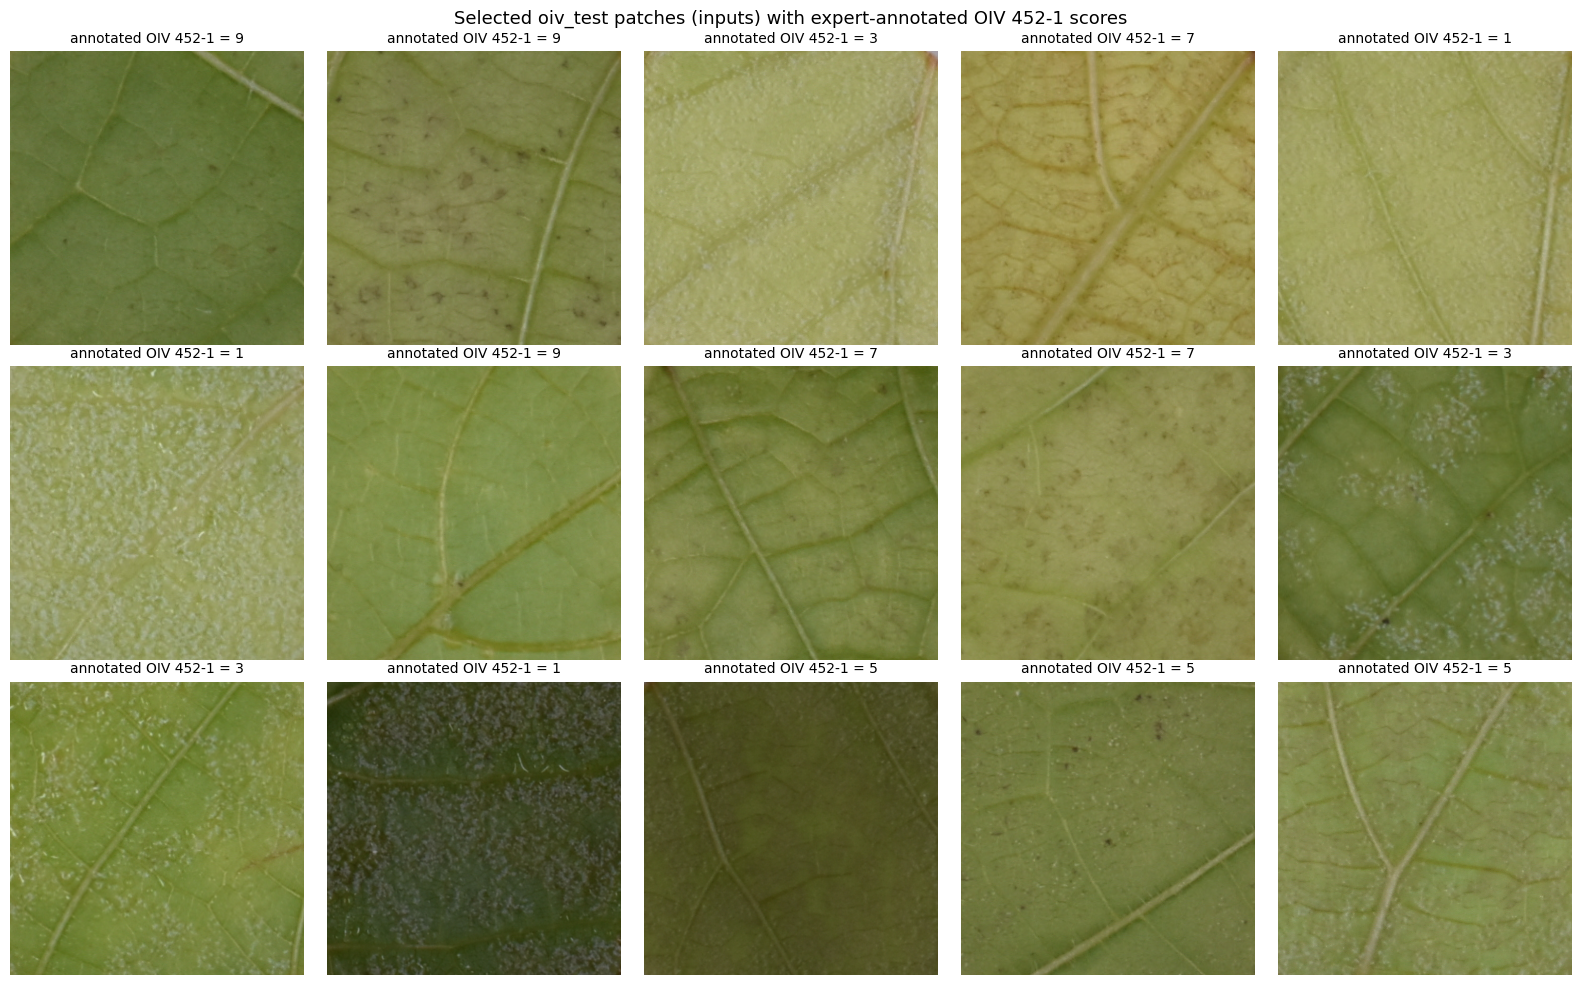

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for ax, (_, row) in zip(axes.reshape(-1), sub.iterrows()):
    img = plt.imread(ROOT / "images/leaf_patches" / row.file_name)
    ax.imshow(img)
    ax.set_title(f"annotated OIV 452-1 = {int(row.oiv)}", fontsize=10)
    ax.set_axis_off()
fig.suptitle("Selected oiv_test patches (inputs) with expert-annotated OIV 452-1 scores", fontsize=13)
plt.tight_layout()
plt.savefig("/content/input_patches_annotated.png", dpi=80, bbox_inches="tight")
plt.show()

## Core method: load the released scorer with the author's code

We import the author's own modules from `/content/oiv_ld_phenotyping/src` (the repository layout their `com_const.py` expects), then load the checkpoint exactly as the authors do in the *Validate* cell of `src/leaf_patch_oiv_predictor.ipynb`: `OivDetPatchesNet.load_from_checkpoint(...)`, followed by repointing `model.path_to_images` at our local copy of `images/leaf_patches`. The device is chosen from the actual runtime (`torch.cuda.is_available()`); no silent CPU fallback happens because the same device string is used for the prediction.

The model applies its own validation preprocessing (`Resize(224)`, `Normalize(mean=0.5, std=0.5)`, `ToTensorV2`) and maps CORN logits to labels 0–4, which correspond to OIV 452-1 levels `[1, 3, 5, 7, 9]`.

**著者コードをそのままインポートしてチェックポイントを読み込み、実行環境に応じてデバイスを設定します。**

In [ ]:
import sys, torch
sys.path.insert(0, str(ROOT / "src"))

import com_const as cc
# repoint the author's path constants at this notebook's /content layout
cc.path_to_root = ROOT
cc.path_to_data = ROOT / "data"
cc.path_to_leaf_patches = ROOT / "images/leaf_patches"

import leaf_patch_oiv_predictor_model as lpopm

model = lpopm.OivDetPatchesNet.load_from_checkpoint(
    str(ROOT / "checkpoints/oiv_scorer/oiv_scorer.ckpt"))
model.path_to_images = ROOT / "images/leaf_patches"

device = "cuda" if torch.cuda.is_available() else "cpu"
lpopm.g_device = device          # module-global device used by predict_sample()
model.selected_device = device
model.eval()
print("device:", device)
print("backbone:", model.backbone, "| ordinal regression:", model.ordinal_regression_model)
print("CORN label -> OIV mapping:", model.labels)

/usr/local/lib/python3.13/dist-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

device:

...

hf_swt_t

| ordinal regression:

corn

CORN label -> OIV mapping:

[1, 3, 5, 7, 9]

### Predict OIV 452-1 on the 15 patches

Runs the author's `model.predict(dataframe)` — each patch is loaded, resized/normalized and passed through the Swin + CORN head; the predicted rank is mapped back to the OIV 452-1 level. The result table shows the expert annotation next to the model prediction.

**著者の `model.predict()` で15枚を推論し、アノテーション値と並べて表示します。**

In [ ]:
import numpy as np

preds = model.predict(sub, show_progress=False)
preds = np.asarray(preds).reshape(-1)
results = sub[["file_name", "oiv"]].copy()
results["predicted_oiv"] = [model.labels[int(p)] for p in preds]
results["annotated_rank"] = (results["oiv"] - 1) // 2      # paper mapping: (oiv-1)//2 -> 0..4
results["predicted_rank"] = preds
display(results)

exact = int((results.annotated_rank == results.predicted_rank).sum())
print(f"exact rank agreement: {exact}/15")

,file_name,oiv,predicted_oiv,annotated_rank,predicted_rank
0,Exp20DM01_inoc1_T6_P07_c_4.png,9,9,4,4
1,Exp20DM01_inoc1_T6_P23_b_1.png,9,7,4,3
2,Exp20DM01_inoc1_T6_P34_a_3.png,3,1,1,0
3,Exp20DM01_inoc1_T6_P44_b_1.png,7,7,3,3
4,Exp20DM01_inoc1_T6_P44_c_4.png,1,5,0,2
5,Exp20DM01_inoc1_T6_P48_b_3.png,1,1,0,0
6,Exp20DM01_inoc2_T6_P02_b_1.png,9,9,4,4
7,Exp20DM01_inoc2_T6_P07_c_4.png,7,7,3,3
8,Exp20DM01_inoc2_T6_P11_a_1.png,7,7,3,3
9,Exp20DM01_inoc2_T6_P34_b_4.png,3,3,1,1


exact rank agreement: 9/15

### Agreement metrics and annotated-versus-predicted view

MAE and MSE are computed on the paper's 0–4 rank scale, as in the paper (test-set MAE 0.188 / MSE 0.206 for the best Swin model — a dataset-level value that this 15-image demo does **not** reproduce). The scatter view is an additional visualization created for this notebook, not an author figure; points on the diagonal are exact rank matches, and the paper reports that predictions never deviate by more than one rank.

**0–4 スケールで MAE/MSE を算出し、アノテーション対予測の散布図を表示します（本ノートブック独自の可視化）。**

MAE (0-4 scale): 0.467   MSE (0-4 scale): 0.600

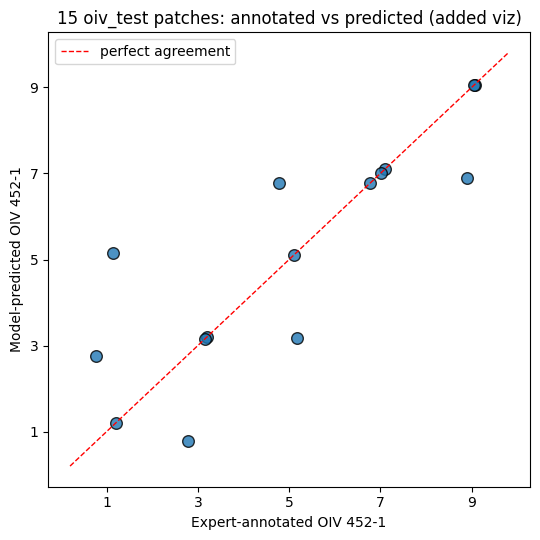

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

mae = mean_absolute_error(results.annotated_rank, results.predicted_rank)
mse = mean_squared_error(results.annotated_rank, results.predicted_rank)
print(f"MAE (0-4 scale): {mae:.3f}   MSE (0-4 scale): {mse:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
jitter = (np.random.default_rng(0).uniform(-0.12, 0.12, len(results)))
ax.scatter(results.annotated_rank + jitter, results.predicted_rank + jitter,
           s=70, edgecolor="k", alpha=0.8)
ax.plot([-0.4, 4.4], [-0.4, 4.4], "r--", linewidth=1, label="perfect agreement")
ax.set_xticks(range(5), model.labels); ax.set_yticks(range(5), model.labels)
ax.set_xlabel("Expert-annotated OIV 452-1"); ax.set_ylabel("Model-predicted OIV 452-1")
ax.set_title("15 oiv_test patches: annotated vs predicted (added viz)")
ax.legend()
plt.tight_layout()
plt.savefig("/content/annotated_vs_predicted.png", dpi=90, bbox_inches="tight")
plt.show()

### Export the result table

Saves the per-patch results as CSV inside the Colab VM (`/content/oiv_predictions.csv`).

**結果表をCSVとして保存します。**

In [ ]:
out_csv = "/content/oiv_predictions.csv"
results.to_csv(out_csv, index=False)
print("saved", out_csv)
print(results.describe().loc[["min", "max"]].to_string())

saved

/content/oiv_predictions.csv

     oiv  predicted_oiv  annotated_rank  predicted_rank
min  1.0            1.0             0.0             0.0
max  9.0            9.0             4.0             4.0

## Interpretation, limitations and validation record

**What this demo shows.** The authors' released Swin CORN scorer (`oiv_scorer.ckpt` @ `9afe4997`) runs unchanged under the author's own code and predicts OIV 452-1 ranks for real test patches; agreement with the expert annotations is reported above on the 0–4 scale.

**What it does not show.** This is a 15-image partial demonstration. It does not reproduce the paper's dataset-level metrics (test MAE 0.188 / MSE 0.206 / accuracy 0.817), the leaf-disc detector, patch extraction, or the genotype-differentiation ANOVA. The paper reports predictions never deviate by more than one rank — check the table above against that claim on this sample only.

**Known limitations.**
- Dependency versions were adapted for today's Colab Python 3.13 (see the runtime cell); the scientific operations are unchanged.
- `model.hr_desc()` from the author's validate cell is not called because it assumes the authors' local directory layout.
- The paper states data/models are available "upon reasonable request" while a public companion repository exists; we use that public repository as released by the authors (AGPL-3.0).

**Provenance.** Paper: Plant Methods 20:90 (2024), DOI 10.1186/s13007-024-01220-4 (CC BY). Code/data/weights: `treizh/oiv_ld_phenotyping` @ `9afe4997f9a24334760db4f8ee97e1fa56398429`, fetched over HTTPS with SHA-256/size verification in this notebook. Study-flow guidance: PhenoPaper investigation `p-83b2a51c60a5a23fa6f5a266fc840633-20260930T120854Z-3642107` (prior research guidance, unverified).

**検証の記録と限界（日本語）:** 本ノートブックは15枚の部分的なデモンストレーションであり、論文のデータセット全体の精度は検証しません。依存関係は現在のColab(Python 3.13)に合わせて調整していますが、科学的な処理は著者コードのままです。